In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
GRID_SIZE = 5
THETA = 1e-6

In [3]:
lake = (0, 0)
fire = (4, 4)
smoke_cells = {(1, 2), (3, 2)}
boulders = {(2, 4), (3, 4)}

actions = ["N", "S", "E", "W", "H"]  

states = []
for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        for water in [0, 1]:
            states.append((x, y, water))

In [4]:

def is_terminal(state):
    x, y, water = state
    if (x, y) in boulders or ((x, y) == fire and water == 1):
        return True
    return False

def move(x, y, action):
    if action == "N":
        return x , y + 1
    if action == "S":
        return x , y - 1
    if action == "E":
        return x + 1, y 
    if action == "W":
        return x - 1, y 
    # action == "H"
    return x, y  

def in_grid(x, y):
    return 0 <= x < GRID_SIZE and 0 <= y < GRID_SIZE


In [5]:
def get_transitions(state, action, reward_func, drift_p_func):
    '''Returns list of (probability, next_state, reward)'''
    x, y, water = state

    if is_terminal(state):
        return [(1.0, state, 0)]   
    
    elif action == "H":
        next_state = (x, y, water)
        reward = reward_func(state, next_state)
        return [(1.0, next_state, reward)]    

    p_intended, p_perp, p_stay = drift_p_func(x, y)

    if action in ("N", "S"):
        perp_actions = ["E", "W"]
    else:
        perp_actions = ["N", "S"]

    transitions = []

    for a in [action, *perp_actions, 'H']:
        nx, ny = move(x, y, a)
        if not in_grid(nx, ny):   # Handle grid boundaries
            nx, ny = x, y
        
        next_water = (nx, ny) == lake
        next_state = (nx, ny, water | next_water)
        
        if a == action:
            p = p_intended
        elif a in perp_actions:
            p = p_perp
        else:  # Hover
            p = p_stay

        transitions.append((p, next_state, reward_func(state, next_state)))

    return transitions

In [6]:
def run_MDP_val_iter(gamma, reward_func, drift_p_func):
    V_history = {}
    policy_history = {}
    step = 0
    V = {s: 0.0 for s in states}

    while True:
        step += 1 
        delta = 0
    
        new_V = V.copy()
        policy = {}

        for s in states:
            if is_terminal(s):
                policy[s] = None
                continue

            new_V[s] = float('-inf')
            for a in actions:
                transitions = get_transitions(s, a, reward_func, drift_p_func)
                total = sum(
                    prob * (reward + gamma * V[next_state])
                    for prob, next_state, reward in transitions
                )

                if total > new_V[s]:
                    new_V[s] = total
                    policy[s] = a
        
            delta = max(delta, abs(V[s] - new_V[s]))

        V.update(new_V)

        if step in [1, 2]:
            key = f"Iter {step}"
            V_history[key] = V.copy()
            policy_history[key] = policy.copy()

        # print(f"[Step {step}] delta={delta:.6f}")

        if delta < THETA:
            V_history["Final"] = V.copy()
            policy_history["Final"] = policy.copy()
            break
    
    return V_history, policy_history

In [7]:
arrow_symbol = {
    "N": "↑",
    "S": "↓",
    "E": "→",
    "W": "←",
    "H": "•"
}

def plot_policy_and_values(ax, title, policy, V_dict, water):
    values = np.zeros((GRID_SIZE, GRID_SIZE))

    for x in range(GRID_SIZE):
        for y in range(GRID_SIZE):
            arrow_text = arrow_symbol.get(policy[(x, y, water)], "")
            values[y, x] = val = V_dict[(x, y, water)]

            ax.text(
                x, y,
                f"{val:.1f}\n{arrow_text}",
                ha="center", va="center", fontsize=9
            )

    ax.imshow(values, cmap="coolwarm", origin="lower")

    ax.set_title(title)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))


## $\gamma = 0.95$

In [8]:
GAMMA = 0.95

def reward_function(state, next_state):
    x, y, water = next_state
    if (x, y) in boulders:
        return -100
    if (x, y) == fire and water == 1:
        return 100
    reward = -1
    if (x, y) in smoke_cells:
        reward -= 10
    return reward

def drift_p_func(x, y):
    '''Intended, Perpendicular, Staying'''
    if (x, y) in smoke_cells:
        return 0.4, 0.1, 0.4
    else:
        return 0.7, 0.1, 0.1

V_history, policy_history = run_MDP_val_iter(GAMMA, reward_function, drift_p_func)

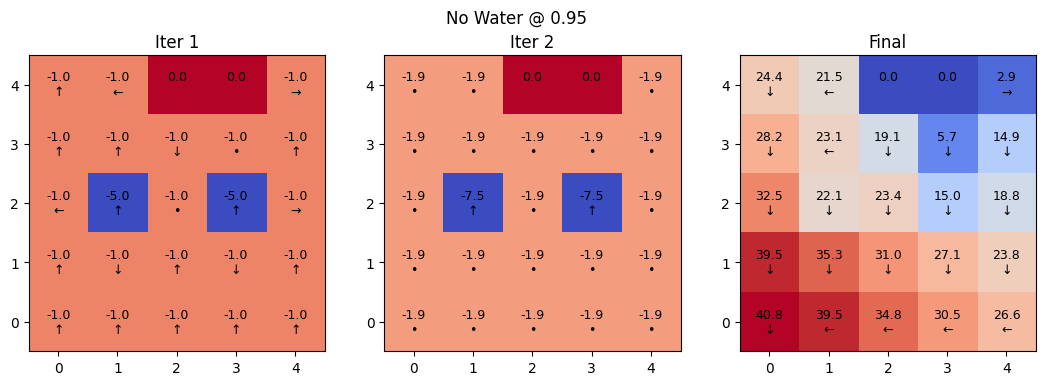

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plt.suptitle(f"No Water @ {GAMMA}")

for ax, title, V_dict, policy in zip(axes.flatten(), V_history.keys(), V_history.values(), policy_history.values()):
    plot_policy_and_values(ax, title, policy, V_dict, 0)
plt.show()

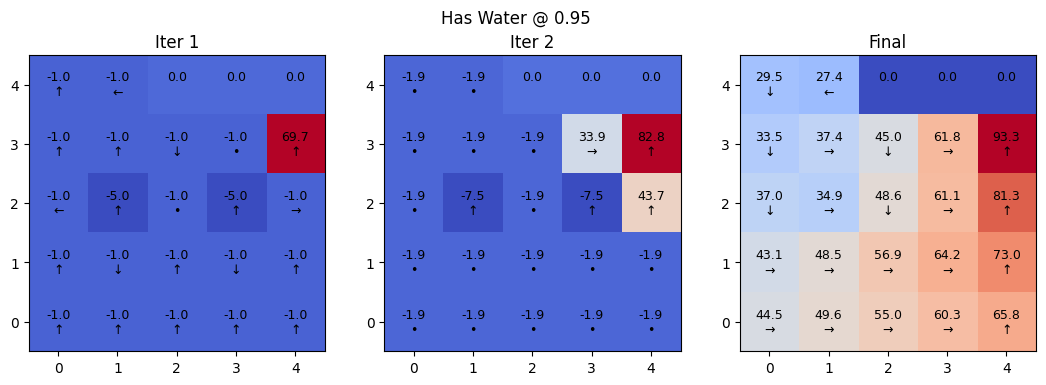

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plt.suptitle(f"Has Water @ {GAMMA}")

for ax, title, V_dict, policy in zip(axes.flatten(), V_history.keys(), V_history.values(), policy_history.values()):
    plot_policy_and_values(ax, title, policy, V_dict, 1)
plt.show()

## $\gamma = 0.3$

In [11]:
GAMMA = 0.3

def reward_function(state, next_state):
    x, y, water = next_state
    if (x, y) in boulders:
        return -100
    if (x, y) == fire and water == 1:
        return 100
    reward = -1
    if (x, y) in smoke_cells:
        reward -= 10
    return reward

def drift_p_func(x, y):
    '''Intended, Perpendicular, Staying'''
    if (x, y) in smoke_cells:
        return 0.4, 0.1, 0.4
    else:
        return 0.7, 0.1, 0.1

V_history, policy_history = run_MDP_val_iter(GAMMA, reward_function, drift_p_func)

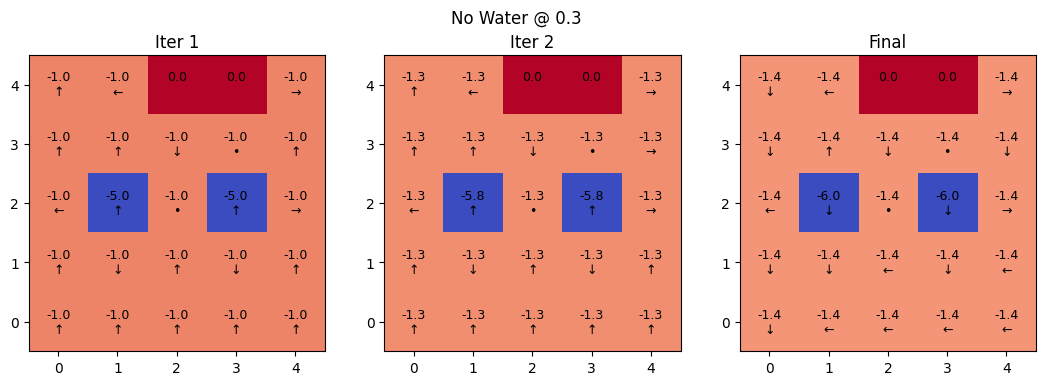

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plt.suptitle(f"No Water @ {GAMMA}")

for ax, title, V_dict, policy in zip(axes.flatten(), V_history.keys(), V_history.values(), policy_history.values()):
    plot_policy_and_values(ax, title, policy, V_dict, 0)
plt.show()

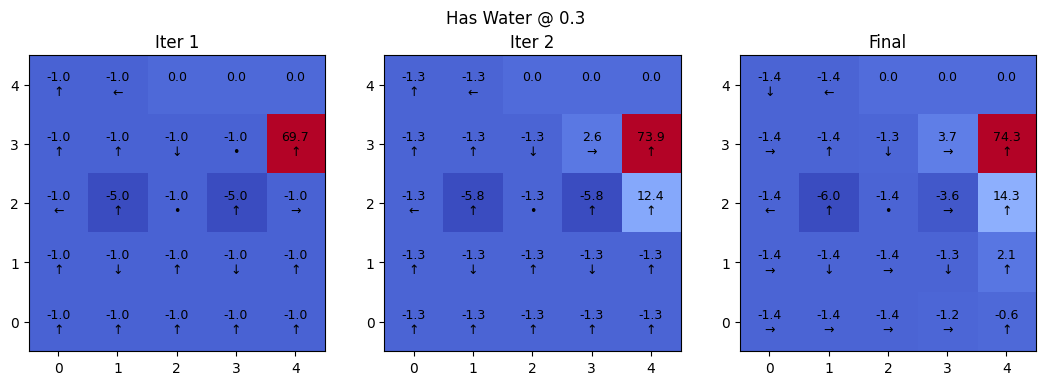

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plt.suptitle(f"Has Water @ {GAMMA}")

for ax, title, V_dict, policy in zip(axes.flatten(), V_history.keys(), V_history.values(), policy_history.values()):
    plot_policy_and_values(ax, title, policy, V_dict, 1)
plt.show()

## $(\gamma = 0.95)$ & $(penalty = -90)$ @ hazardous

In [14]:
GAMMA = 0.95

def reward_function(state, next_state):
    x, y, water = next_state
    if (x, y) in boulders:
        return -100
    if (x, y) == fire and water == 1:
        return 100
    reward = -1
    if (x, y) in smoke_cells:
        reward -= 90
    return reward

def drift_p_func(x, y):
    '''Intended, Perpendicular, Staying'''
    if (x, y) in smoke_cells:
        return 0.4, 0.1, 0.4
    else:
        return 0.7, 0.1, 0.1

V_history, policy_history = run_MDP_val_iter(GAMMA, reward_function, drift_p_func)

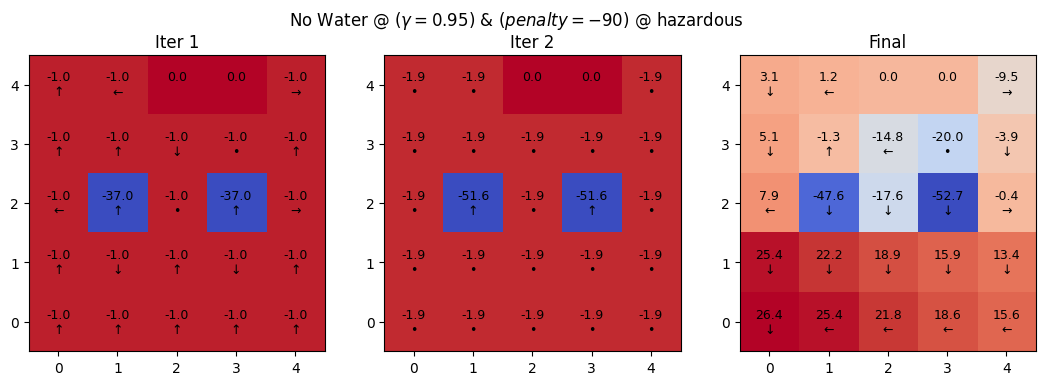

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plt.suptitle(f"No Water @ $(\gamma = 0.95)$ & $(penalty = -90)$ @ hazardous")

for ax, title, V_dict, policy in zip(axes.flatten(), V_history.keys(), V_history.values(), policy_history.values()):
    plot_policy_and_values(ax, title, policy, V_dict, 0)
plt.show()

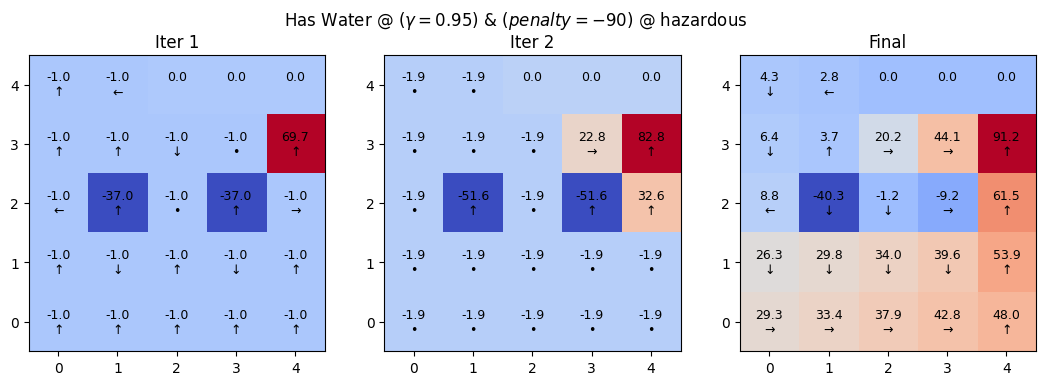

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plt.suptitle(f"Has Water @ $(\gamma = 0.95)$ & $(penalty = -90)$ @ hazardous")

for ax, title, V_dict, policy in zip(axes.flatten(), V_history.keys(), V_history.values(), policy_history.values()):
    plot_policy_and_values(ax, title, policy, V_dict, 1)
plt.show()

### + stronger winds

In [17]:
def drift_p_func(x, y):
    return 0.40, 0.25, 0.1

V_history, policy_history = run_MDP_val_iter(GAMMA, reward_function, drift_p_func)

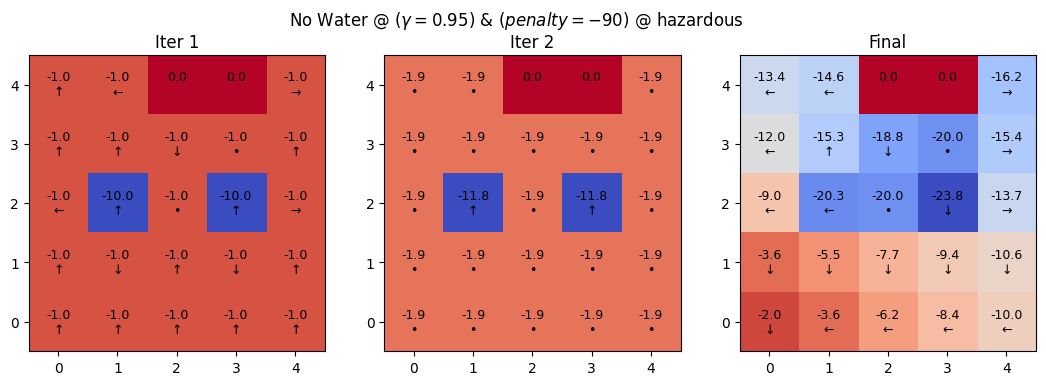

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plt.suptitle(f"No Water @ $(\gamma = 0.95)$ & $(penalty = -90)$ @ hazardous")

for ax, title, V_dict, policy in zip(axes.flatten(), V_history.keys(), V_history.values(), policy_history.values()):
    plot_policy_and_values(ax, title, policy, V_dict, 0)
plt.show()

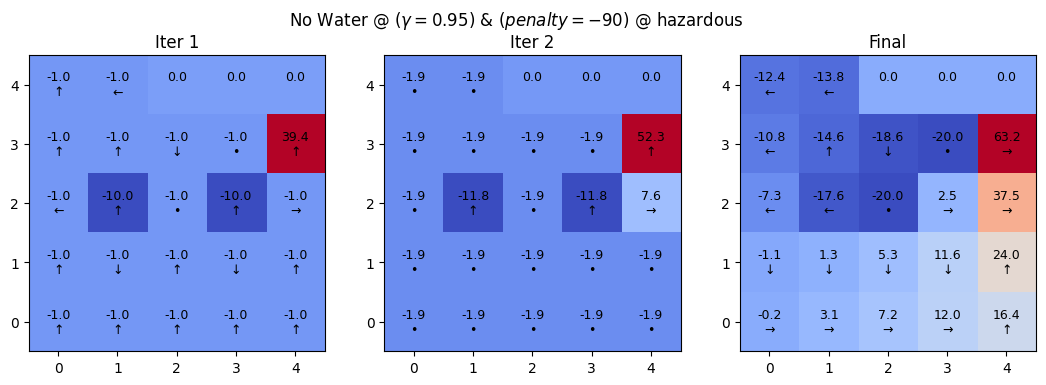

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plt.suptitle(f"No Water @ $(\gamma = 0.95)$ & $(penalty = -90)$ @ hazardous")

for ax, title, V_dict, policy in zip(axes.flatten(), V_history.keys(), V_history.values(), policy_history.values()):
    plot_policy_and_values(ax, title, policy, V_dict, 1)
plt.show()